# **4. 동적 웹 크롤링 과제**

## **과제: 스팀(Steam) 게임 리뷰 수집 및 분석**

- https://steamcommunity.com/
- **리뷰 사이트:** https://steamcommunity.com/app/게임ID/reviews/

![image.png](attachment:4edaee8c-ed8f-46f4-9585-5bae87128927:image.png)

---

## **과제 개요**

- 스팀(Steam) 커뮤니티에서 특정 게임의 사용자 리뷰를 수집
- 무한 스크롤을 통해 200개 이상의 리뷰 데이터 수집 및 저장
- 수집한 데이터를 분석하여 게임의 추천/비추천 비율 파악

---

## **구현 단계**

### **1. 무한 스크롤 처리**

- 스팀 리뷰 페이지 접속
- JavaScript를 이용한 페이지 스크롤 자동화
- 새로운 리뷰 로딩 대기 및 반복
- 원하는 개수(200개 이상)까지 수집

### **2. 리뷰 데이터 추출**

- BeautifulSoup 또는 Selenium으로 리뷰 카드 파싱
- 추천/비추천, 플레이 시간, 리뷰 내용, 작성 날짜 추출
- 도움됨 수, 사용자 이름, 댓글 수 추출
- 예외 처리 구현 (정보가 없는 경우)

### **3. 데이터 저장 및 정제**

- 수집한 모든 데이터를 pandas DataFrame으로 변환
- 플레이 시간, 도움됨 수 등 숫자 데이터 변환
- JSON 형식으로 저장

### **4. 데이터 분석 및 시각화**

- 추천/비추천 비율 계산 및 파이 차트 생성
- 평균 플레이 시간 분석 및 히스토그램

---

### **0. 환경 설정**

In [19]:
# 1. 환경 설정 및 드라이버 함수 정의
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from pprint import pprint
import time, re

def get_chrome_driver():
    """봇 감지를 회피하는 최적화된 Chrome 드라이버 생성"""
    
    chrome_options = Options()
    
    # ========== 기본 옵션 ==========
    chrome_options.add_argument('--start-maximized')
    chrome_options.add_argument('--disable-blink-features=AutomationControlled')
    
    # ========== 자동화 감지 회피 ==========
    chrome_options.add_experimental_option("excludeSwitches", ["enable-automation"])
    chrome_options.add_experimental_option('useAutomationExtension', False)
    
    # ========== User-Agent 설정 ==========
    user_agent = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
    chrome_options.add_argument(f'user-agent={user_agent}')

    # ========== 드라이버 생성 ==========
    driver = webdriver.Chrome(options=chrome_options)
    
    # ========== JavaScript를 통한 추가 위장 ==========
    driver.execute_cdp_cmd('Page.addScriptToEvaluateOnNewDocument', {
        'source': '''
            Object.defineProperty(navigator, 'webdriver', {
                get: () => undefined
            })
        '''
    })
    
    return driver

In [41]:
# 1. 스팀 리뷰 페이지 접속
# 드라이버 생성
driver = get_chrome_driver()

# 스팀 리뷰 페이지 URL
url = "https://steamcommunity.com/"

# 페이지 접속
driver.get(url)

# 페이지가 완전히 로드될 때까지 잠시 대기
time.sleep(3)

print(f"페이지 접속 완료: {driver.title}")

# reviews 이동
# 방법1: 화면에 “Reviews”라는 글자가 보이는 링크(a 태그)를 직접 찾음
wait = WebDriverWait(driver, 10)
# reviews_btn = wait.until(
#     EC.element_to_be_clickable((By.LINK_TEXT, "Reviews")))
# reviews_btn.click()

# 방법2: DOM 트리 구조(HTML 계층) 를 따라가서 정확한 위치의 요소를 클릭
reviews_btn = wait.until(
    EC.element_to_be_clickable((By.XPATH, '//*[@id="ModalContentContainer"]/div[1]/div[2]/div[1]/a[9]'))
)
reviews_btn.click()
time.sleep(3)

recent_btn = wait.until(
    EC.element_to_be_clickable((By.XPATH, '//*[@id="ModalContentContainer"]/div[1]/div[3]/div[1]/a[2]/span'))
)
recent_btn.click()



페이지 접속 완료: Steam Community


---

### **1. 무한 스크롤 처리 & 2. 리뷰 데이터 추출**

recommended -> 1 그렇다. 0 그렇지 않다.
play_time
content
date
helpful
user_name
reply

In [42]:

seen_reviews = set()
 # 모든 게임 리뷰 정보를 저장할 리스트
game_reviews = []

 # 중복 방지를 위한 URL 세트
seen_urls = set()

 # 스크롤 설정
scroll_pause_time = 2  # 스크롤 후 대기 시간

    
print(f"\n{'='*80}")
print(f"리뷰 수집 시작")
print(f"{'='*80}\n")

while True:
        # 현재 페이지의 모든 리뷰 찾기
        search_results = driver.find_elements(By.CSS_SELECTOR, "div.apphub_Card.modalContentLink.interactable")
        
        # 각 뉴스 기사 정보 추출
        for review in search_results:
            review_info = {
                'recommended': None, #-> 1 그렇다. 0 그렇지 않다.
                'play_time': None,
                'content': None,
                'date': None,
                'helpful': None,
                'game_name': None,
                'reply': None,
            }
            
            try:
                # URL 먼저 확인 (중복 체크용)
                review_url = review.get_attribute("data-modal-content-url")

                # 중복이면 건너뛰기
                if review_url in seen_reviews:
                    continue
                else:
                    seen_reviews.add(review_url)

            except:
                continue
            try:
                # 추천/비추천 ------------------------------------
                recommended = review.find_element(By.CSS_SELECTOR, "div.title")
                # 추천 여부 1/0 변환
                if "Not" in recommended.text:
                    review_info["recommended"] = 0
                else:
                    review_info["recommended"] = 1

            except Exception as e:
                print("추천 여부 파싱 실패:", e)
                review_info["recommended"] = None  # 혹은 0으로 기본값 설정
            
            try:
                # 플레이 시간 (숫자만 추출)------------------------------------
                play_time_el = review.find_element(By.CSS_SELECTOR, "div.hours")
                play_time_txt = play_time_el.text.strip()
                match = re.search(r"([\d\.]+)", play_time_txt)
                review_info["play_time"] = float(match.group(1)) if match else None

            except Exception as e:
                print("플레이 시간 파싱 실패:", e)
                review_info["play_time"] = None
            
            try:
                # 작성 날짜 (앞에 'Posted:' 뺴고 추출)------------------------------------
                date_el = review.find_element(By.CSS_SELECTOR, "div.date_posted")
                date_txt = date_el.text.strip()
                date = re.sub(r"^Posted:\s*","",date_txt)
                review_info['date'] = date
            except:
                pass
            
            try:
                # 리뷰 내용 (앞에 'Posted:' 뺴고 추출)------------------------------------
                content_el = review.find_element(By.CSS_SELECTOR, "div.apphub_CardTextContent")
                content_txt = content_el.text.strip()
                content = content_txt.replace(date_el.text, "").strip()
                review_info['content'] = content
            except:
                pass
            
            try:
                # 도움됨 수 (숫자만 추출)------------------------------------
                helpful_el = review.find_element(By.CSS_SELECTOR, "div.found_helpful")
                helpful_txt =  helpful_el.text.strip()
                match = re.search(r"([\d,]+)", helpful_txt)   # 쉼표 포함 숫자
                review_info["helpful"] = int(match.group(1).replace(",", "")) if match else 0

            except Exception as e:
                print("도움됨 수 파싱 실패:", e)
                review_info["helpful"] = None
            
            try:
                # 게임 이름 ------------------------------------
                name = review.find_element(By.CSS_SELECTOR, "div.apphub_CardContentAuthorBlock.tall div.apphub_CardContentAppName a")
                game_name = name.text.strip()
                review_info['game_name'] = game_name
            except:
                pass
            
            try:
                # 댓글 수 ------------------------------------
                reply = review.find_element(By.CSS_SELECTOR, "div.apphub_CardCommentCount.alignUserReviews")
                review_info['reply'] = reply.text
            except:
                pass
            
            
            
            # 리스트에 저장
            game_reviews.append(review_info)
            
            # 개별 기사 출력
            print(f"[{len(game_reviews)}] 새 리뷰 수집")
            print(review_info)
            print()
        
        # 현재까지 수집한 기사 수 출력
        print(f"{'='*80}")
        print(f"현재까지 수집된 기사: {len(game_reviews)}개")
        print(f"{'='*80}\n")
        
        # 스크롤 내려서 새 리뷰 로딩
        driver.execute_script("window.scrollBy(0, 1000);")
        time.sleep(1)

        # 수집된 리뷰가 200개 넘으면 종료
        if len(game_reviews) >= 200:
            break

print(f"총 {len(game_reviews)}개 수집 완료!")





리뷰 수집 시작

[1] 새 리뷰 수집
{'recommended': 1, 'play_time': 11.2, 'content': 'Very realistic Emergency Service Simulator.', 'date': 'October 31', 'helpful': 0, 'game_name': 'Flashing Lights', 'reply': '0'}

[2] 새 리뷰 수집
{'recommended': 1, 'play_time': 9.1, 'content': "EARLY ACCESS REVIEW\nI'M ASCENDING!", 'date': 'October 31', 'helpful': 0, 'game_name': 'skate.', 'reply': '0'}

[3] 새 리뷰 수집
{'recommended': 1, 'play_time': 4.2, 'content': 'its better than everyone is saying', 'date': 'October 31', 'helpful': 0, 'game_name': 'Battlefield™ 6', 'reply': '0'}

[4] 새 리뷰 수집
{'recommended': 1, 'play_time': 281.0, 'content': 'EARLY ACCESS REVIEW\nThis game made me poop myself.', 'date': 'October 31', 'helpful': 0, 'game_name': 'Phasmophobia', 'reply': '0'}

[5] 새 리뷰 수집
{'recommended': 1, 'play_time': 8.5, 'content': 'How is this cheaper than battlefield 6', 'date': 'October 31', 'helpful': 0, 'game_name': 'ARC Raiders', 'reply': '0'}

[6] 새 리뷰 수집
{'recommended': 1, 'play_time': 9.4, 'content': 'Very f

---

### **3. 데이터 저장 및 정제**

- 수집한 모든 데이터를 pandas DataFrame으로 변환
- 플레이 시간, 도움됨 수 등 숫자 데이터 변환
- JSON 형식으로 저장



In [43]:
import pandas as pd
from datetime import datetime

df = pd.DataFrame(game_reviews)
    
# 데이터프레임 정보 출력
print("[데이터 미리보기]")
display(df.head())

# # ========== 파일 저장 ==========
# # 현재 시간을 파일명에 포함
# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# # JSON 저장
# json_filename = f"naver_news_{timestamp}.json"
# df.to_json(json_filename, orient='records', force_ascii=False, indent=2)
# print(f"\nJSON 저장 완료: {json_filename}")

[데이터 미리보기]


,recommended,play_time,content,date,helpful,game_name,reply
0,1,11.2,Very realistic Emergency Service Simulator.,October 31,0,Flashing Lights,0
1,1,9.1,EARLY ACCESS REVIEW\nI'M ASCENDING!,October 31,0,skate.,0
2,1,4.2,its better than everyone is saying,October 31,0,Battlefield™ 6,0
3,1,281.0,EARLY ACCESS REVIEW\nThis game made me poop my...,October 31,0,Phasmophobia,0
4,1,8.5,How is this cheaper than battlefield 6,October 31,0,ARC Raiders,0


---

### **4. 데이터 분석 및 시각화**

- 추천/비추천 비율 계산 및 파이 차트 생성
- 평균 플레이 시간 분석 및 히스토그램

In [ ]:
# 인기순으로해도 최신순으로해도 Not Recommend가 없음 하
df['recommended'].nunique()

1

In [ ]:
import matplotlib.pyplot as plt

# df['play_time'] = df['play_time'].fillna(0)

# 추천/비추천 비율 계산 및 파이 차트 생성 (근데 Not Recommended가 없음!!!)
recommended_cnt = df['recommended'].value_counts().sort_index()
plt.figure(figsize=(5,5))
plt.pie(recommended_cnt, labels=['recommended', 'unrecommended'],autopct='%1.1f%%')
plt.title('Proportion of Recommended')
plt.show()

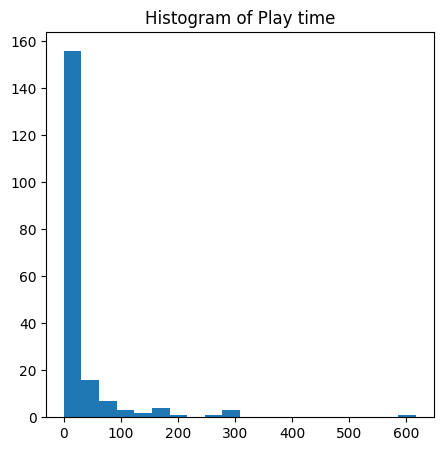

In [45]:
# 평균 플레이 시간 분석 및 히스토그램
plt.figure(figsize=(5,5))
plt.hist(df['play_time'],bins=20)
plt.title('Histogram of Play time')
plt.show()